In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from src.data.load_data import load_resumes
from src.data.preprocess import clean_text
from src.models.classifier import train_classifier, predict_category

In [3]:
resumes = load_resumes()
resumes['clean_resume'] = resumes['Resume'].apply(clean_text)
print("✅ Data ready:", resumes.shape)
print(resumes[['Category', 'clean_resume']].head(3))

✅ Data ready: (962, 3)
       Category                                       clean_resume
0  Data Science  skills programming languages python pandas num...
1  Data Science  education details may may uit rgpv data scient...
2  Data Science  areas interest deep learning control system de...


In [4]:
model = train_classifier(resumes, text_col='clean_resume', label_col='Category')
print("✅ Model trained and saved to models/classifier.pkl!")

=== Classification Report ===
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       0.83      1.00      0.91         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       1.00      1.00      1.00         6
                       HR       1.00      1.00      1.00         9
                   Hadoop      

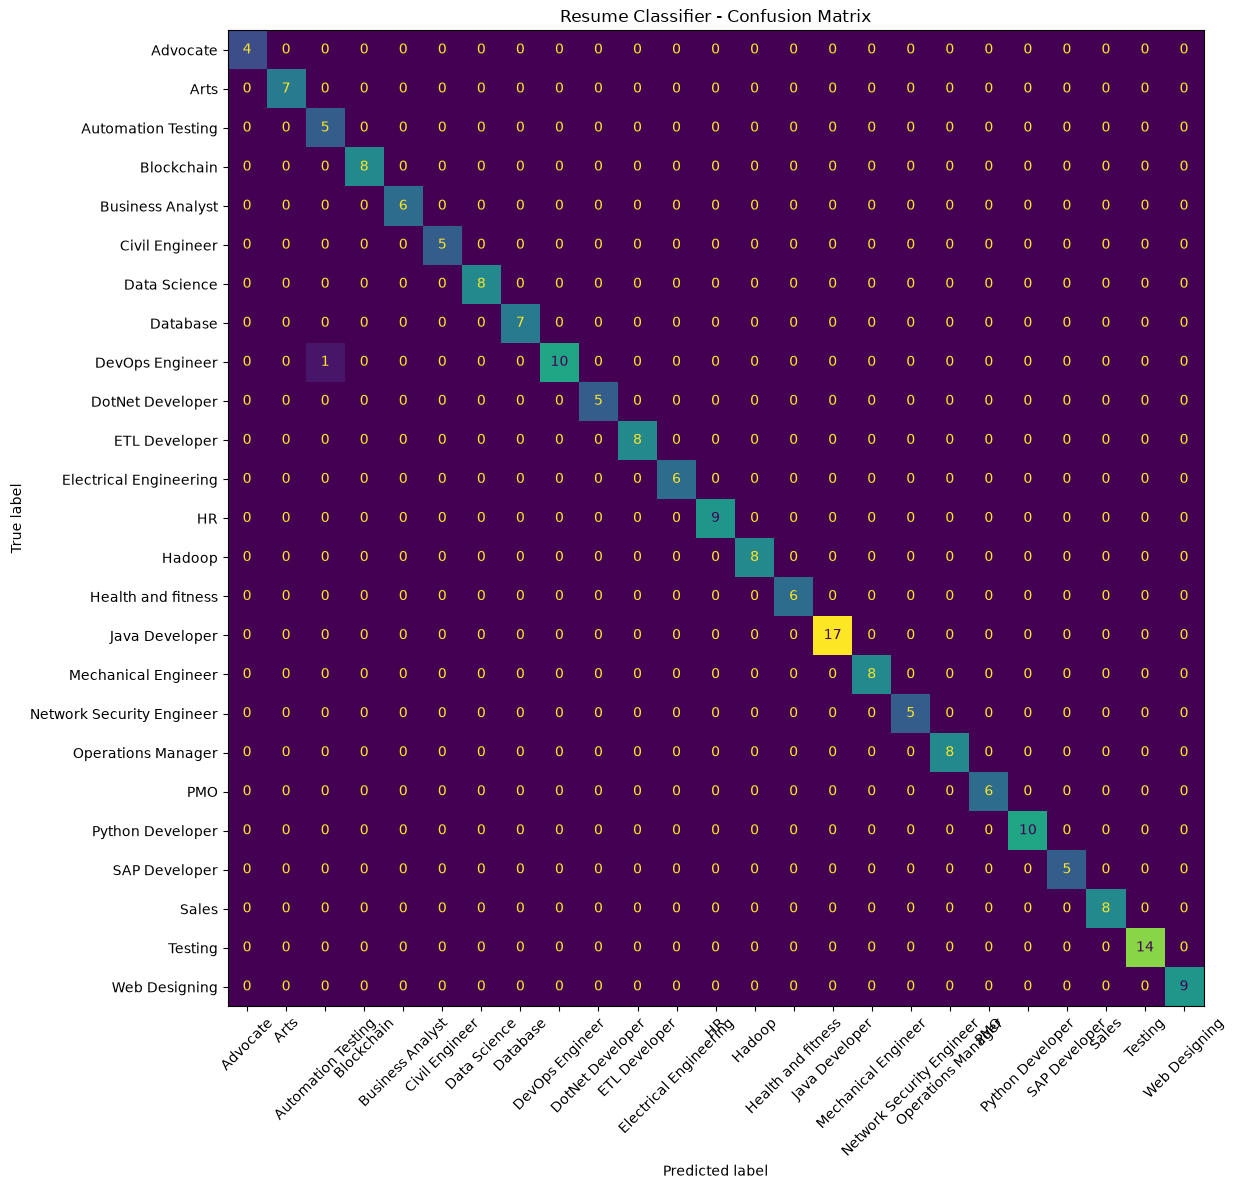

In [5]:
import joblib
pipe = joblib.load('../models/classifier.pkl')

X_train, X_test, y_train, y_test = train_test_split(
    resumes['clean_resume'], resumes['Category'],
    test_size=0.2, random_state=42, stratify=resumes['Category']
)
y_pred = pipe.predict(X_test)

fig, ax = plt.subplots(figsize=(16, 12))
cm = confusion_matrix(y_test, y_pred, labels=pipe.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe.classes_)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Resume Classifier - Confusion Matrix')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png')
plt.show()

In [6]:
sample_resume = resumes['Resume'].iloc[10]
clean = clean_text(sample_resume)
predicted = predict_category(clean)
actual = resumes['Category'].iloc[10]

print(f"Actual Category   : {actual}")
print(f"Predicted Category: {predicted}")
print(f"Match: {'✅ Correct!' if actual == predicted else '❌ Wrong'}")

Actual Category   : Data Science
Predicted Category: Data Science
Match: ✅ Correct!


In [7]:
correct = 0
total = 20
for i in range(total):
    clean = clean_text(resumes['Resume'].iloc[i])
    pred  = predict_category(clean)
    actual = resumes['Category'].iloc[i]
    status = '✅' if pred == actual else '❌'
    print(f"{status} Actual: {actual:25} | Predicted: {pred}")
    if pred == actual:
        correct += 1

print(f"\nAccuracy on sample: {correct}/{total} = {correct/total*100:.1f}%")

✅ Actual: Data Science              | Predicted: Data Science
✅ Actual: Data Science              | Predicted: Data Science
✅ Actual: Data Science              | Predicted: Data Science
✅ Actual: Data Science              | Predicted: Data Science
✅ Actual: Data Science              | Predicted: Data Science
✅ Actual: Data Science              | Predicted: Data Science
✅ Actual: Data Science              | Predicted: Data Science
✅ Actual: Data Science              | Predicted: Data Science
✅ Actual: Data Science              | Predicted: Data Science
✅ Actual: Data Science              | Predicted: Data Science
✅ Actual: Data Science              | Predicted: Data Science
✅ Actual: Data Science              | Predicted: Data Science
✅ Actual: Data Science              | Predicted: Data Science
✅ Actual: Data Science              | Predicted: Data Science
✅ Actual: Data Science              | Predicted: Data Science
✅ Actual: Data Science              | Predicted: Data Science
✅ Actual

✅ ROC-AUC Score (macro): 1.0000
✅ ROC-AUC Score (weighted): 1.0000


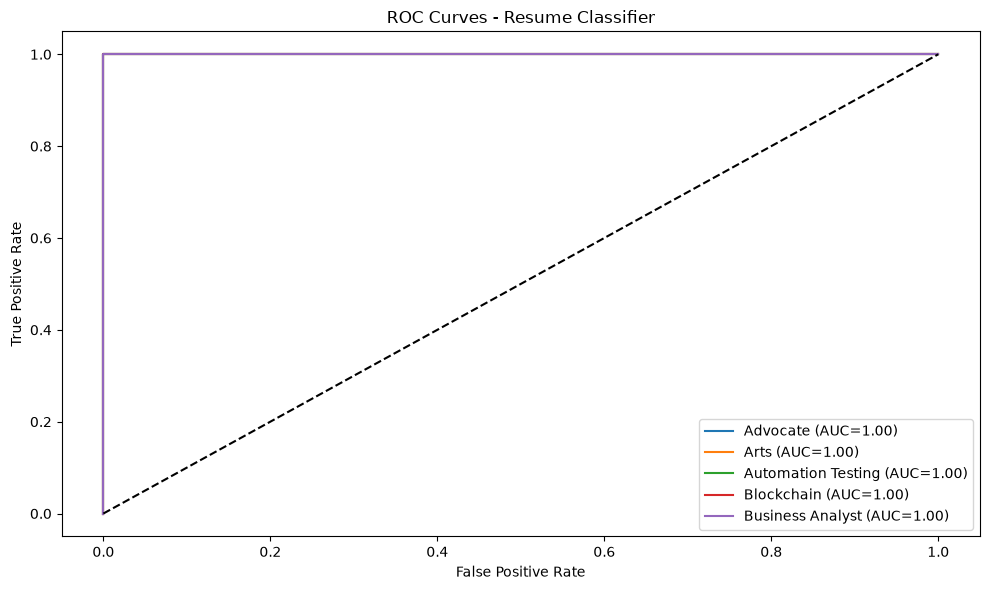

✅ ROC curve saved!


In [8]:
# === ROC-AUC Evaluation ===
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
import numpy as np

# Get probability predictions
pipe = joblib.load('../models/classifier.pkl')
X_train, X_test, y_train, y_test = train_test_split(
    resumes['clean_resume'], resumes['Category'],
    test_size=0.2, random_state=42, stratify=resumes['Category']
)

# Get probabilities
y_prob = pipe.predict_proba(X_test)
classes = pipe.classes_

# Binarize labels
y_test_bin = label_binarize(y_test, classes=classes)

# Compute ROC-AUC
roc_auc = roc_auc_score(y_test_bin, y_prob, 
                         multi_class='ovr', average='macro')
print(f"✅ ROC-AUC Score (macro): {roc_auc:.4f}")
print(f"✅ ROC-AUC Score (weighted): {roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='weighted'):.4f}")

# Plot ROC curve for top 5 categories
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 6))
for i, category in enumerate(classes[:5]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc_i = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{category} (AUC={roc_auc_i:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Resume Classifier')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/roc_curve.png')
plt.show()
print("✅ ROC curve saved!")